This week's tutorial is focused on:
- sufficient statistics
- point estimators (Maximum Likelihood, Method of Moments)

In [ ]:
import numpy as np
import numpy.random as rd
from scipy.stats import norm
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

# Maximum Likelihood or Method of Moments?

In Exercise 7 of Tutorial 4, you have derived both the ML and the MoM estimators for a sample following the distribution

$$f(x|\theta) = \frac{1}{\theta}$$

where $x \in [0, \theta]$.

---
### Maximum Likelihood

- The actual estimator:

$$\hat \theta = \max_i\{X_i\} = X_{(n)}$$

- The bias:

$$\theta - \text{E}[\hat \theta] = \frac{1}{n+1}\theta$$

- The variance:

$$\text{Var}[\hat \theta] = \frac{n}{(n+2)(n+1)^2} \theta^2$$

- The mean squared error:

$$\text{MSE} = \text{E}[(\hat \theta - \theta)^2] = \frac{2}{(n+1)(n+2)} \theta^2$$

- Probability density function:

$$f_{\text{ML}}(x | \theta) = \frac{n}{\theta^n} x^{n-1} 1_{[0, \theta]}(x)$$

---
### Method of Moments

- The actual estimator:

$$\bar \theta = 2 \bar X$$

- The bias:

$$\theta - \text{E}[\bar \theta] = 0$$

- The variance:

$$\text{Var}[\bar \theta] = \frac{1}{3n} \theta^2$$

- The mean squared error:

$$\text{MSE} = \text{E}[(\bar \theta - \theta)^2] = \frac{1}{3n} \theta^2$$

- Probability density function: asymptotically that of $N\left(\theta, \frac{\theta^2}{3n} \right)$ (via the CLT)

---
### Maximum Likelihood adjusted

- The actual estimator:

$$\hat \theta_a = \max_i\{X_i\} = \frac{n+1}{n} X_{(n)}$$

- The bias:

$$\theta - \text{E}[\hat \theta_a] = 0$$

- The variance:

$$\text{Var}[\hat \theta_a] = \frac{1}{n(n+2)} \theta^2$$

- The mean squared error:

$$\text{MSE} = \text{E}[(\hat \theta_a - \theta)^2] = \frac{1}{n(n+2)} \theta^2$$

- Probability density function (via the previous):

$$f_{\text{MLadj}}(x | \theta) = \left( 1 - \frac{1}{n+1} \right)^{n+1} \frac{n+1}{\theta^n} x^{n-1} 1_{[0, \theta]}(x)$$

In [ ]:
# - Functions to make the process more concise

def generate_data(theta, n, seed = None):
  """
  The functions generates an i.i.d. sample of size n, according to the
  distribution in the exercise with parameter $\theta$
  """

  # Set the seed for reproducibility of results
  if seed is not None:
    rd.seed(seed)

  return rd.uniform(low = 0, high = theta, size=n)

def estimator(data, type_est):
  """
  The function returns the value of an estimator, given some sample "data"
  If type = "ML", it is the Maximum Likelihood estimator. Otherwise, it is the
  Method of Moments estimator
  """

  if type_est == "ML":
    return np.max(data)
  elif type_est == "MoM":
    return 2 * np.average(data)
  else:
    n = len(data)
    return ((n+1)/n) * np.max(data)

def theoretical_bias(theta, n, type_est):
  """
  The function returns the value for the *theoretical* value of an estimator's bias,
  given the size of the sample and the actual paramter value
  """

  if type_est == "ML":
    return theta/(n+1)
  else:
    return 0

def theoretical_variance(theta, n, type_est):
  """
  The function returns the value for the *theoretical* value of an estimator's variance,
  given the size of the sample and the actual paramter value
  """

  if type_est == "ML":
    return (n * theta**2)/((n+2)*(n+1)**2)
  elif type_est == "MoM":
    return (theta**2)/( 3 * n )
  else:
    return theta**2 / ( n * (n+2) )

def theoretical_mse(theta, n, type_est):
  """
  The function returns the value for the *theoretical* value of an estimator's MSE,
  given the size of the sample and the actual paramter value
  """

  if type_est == "ML":
    return (2 * theta**2)/( (n+2)*(n+1) )
  elif type_est == "MoM":
    return (theta**2)/( 3 * n )
  else:
    return theta**2 / ( n * (n+2) )

def pdf(x, theta, n, type_est):
  """
  The function returns the probability density function for each type of estimator,
  evaluated at some point $x$
  """

  # Design the function to work with arrays directly
  out = np.zeros_like(x)
  mask = (x <= theta) & (x >= 0)

  if type_est == "ML":
    out[mask] = (n/theta**n) * x[mask]**(n - 1)
  elif type_est == "MoM":
    out = norm.pdf(x, loc = theta, scale = theta/(np.sqrt(3*n)))
  else:
    out[mask] = ( 1 - 1/(n+1) )**(n+1) * ( (n+1) /theta**n) * x[mask]**(n - 1)

  return out

Time to demonstrate the estimators in action!

### 1. Warm up

- Generate some data
- Find the estimators

In [ ]:
# Set some values for the parameters
theta = 1.2
n = 100

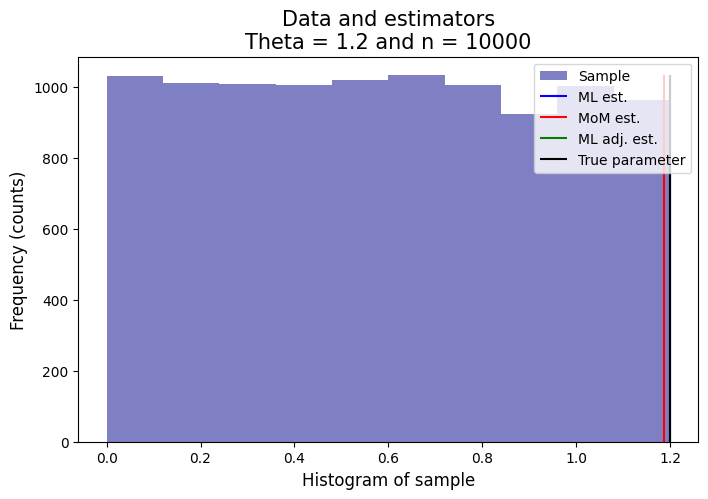

ML est.: 1.1996612079433566
MoM est.: 1.1859829384423193
ML adj. est.: 1.1997811740641509


In [ ]:
data = generate_data(theta, n, seed = 42)

# Display the data in a histogram
plt.figure(figsize = (8, 5))

hist_, _, _ = plt.hist(data, bins=10, color = "darkblue", alpha = 0.5, label = "Sample")

plt.vlines(x = estimator(data, type_est="ML"), ymin=0, ymax=np.max(hist_),
           label = "ML est.", color = "blue")
plt.vlines(x = estimator(data, type_est="MoM"), ymin=0, ymax=np.max(hist_),
           label = "MoM est.", color = "red")
plt.vlines(x = estimator(data, type_est="MLadj"), ymin=0, ymax=np.max(hist_),
           label = "ML adj. est.", color = "green")
plt.vlines(x = theta, ymin=0, ymax=np.max(hist_), label = "True parameter", color = "black")

plt.title(f"Data and estimators\nTheta = {theta} and n = {n}", fontsize = 15)
plt.xlabel("Histogram of sample", fontsize = 12)
plt.ylabel("Frequency (counts)", fontsize = 12)

plt.legend()
plt.show()

print("ML est.:", estimator(data, type_est="ML"))
print("MoM est.:", estimator(data, type_est="MoM"))
print("ML adj. est.:", estimator(data, type_est="MLadj"))

#### 2. Distribution of the estimators

- How are the estimators distributed? Estimate by Monte Carlo and compare the estimated distribution with the theoretical result from the tutorial

- Highlight the true value, expected value and variance

---

**Comments**

- We see that the simulated results and the theoretical values agree quite well. Try to increase N_data, you will see that the agreement will become better and better

- Which estimator would you prefer? You can see visually the differences between the three options

- The best estimator, in my opinion, is the adjusted ML variant. It is unbiased, with variance in between the two other options, towards the smaller value

In [ ]:
# Generate many data sets of size n
# Compute the estimators for all values

rd.seed(42)

N_data = 1000
theta_ML_list = np.empty(N_data)
theta_MoM_list = np.empty(N_data)
theta_MLadj_list = np.empty(N_data)

for i in range(N_data):
  data = generate_data(theta, n)

  theta_ML_list[i] = estimator(data, type_est="ML")
  theta_MoM_list[i] = estimator(data, type_est="MoM")
  theta_MLadj_list[i] = estimator(data, type_est="MLadj")

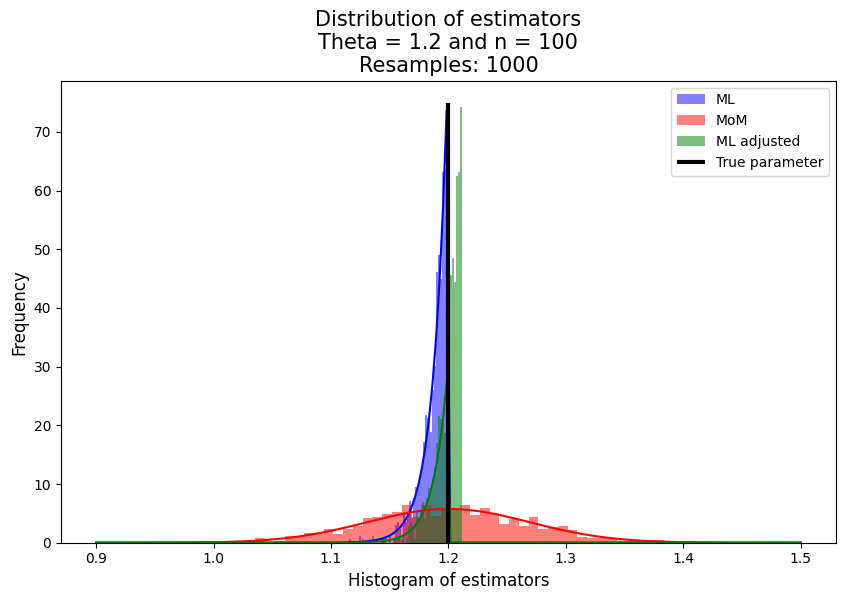

In [ ]:
x_list = np.linspace(0.75 * theta, 1.25 * theta, 200)

# Plot
plt.figure(figsize = (10, 6))

hist1, _, _ = plt.hist(theta_ML_list, bins=50, color = "blue", alpha = 0.5,
                       label = "ML", density=True)
hist2, _, _ = plt.hist(theta_MoM_list, bins=50, color = "red", alpha = 0.5,
                       label = "MoM", density=True)
hist3, _, _ = plt.hist(theta_MLadj_list, bins=50, color = "green", alpha = 0.5,
                       label = "ML adjusted", density=True)
upper_lim = np.max([np.max(hist1), np.max(hist2), np.max(hist3)])

plt.plot(x_list, pdf(x_list, theta, n, type_est="ML"), color = "blue")
plt.plot(x_list, pdf(x_list, theta, n, type_est="MoM"), color = "red")
plt.plot(x_list, pdf(x_list, theta, n, type_est="MLadj"), color = "green")

plt.vlines(x = theta, ymin=0, ymax=upper_lim, label = "True parameter",
           color = "black", lw = 3)

plt.title(f"Distribution of estimators\nTheta = {theta} and n = {n}\nResamples: {N_data}",
          fontsize = 15)
plt.xlabel("Histogram of estimators", fontsize = 12)
plt.ylabel("Frequency", fontsize = 12)

plt.legend()
plt.show()

In [ ]:
# - Bias

bias_ML = theta - np.average(theta_ML_list)
bias_MoM = theta - np.average(theta_MoM_list)
bias_MLadj = theta - np.average(theta_MLadj_list)

print("Bias empirical ML:", bias_ML)
print("Bias empirical MoM:", bias_MoM)
print("Bias empirical ML adjusted:", bias_MLadj)

print()
print("The MoM estimator's bias is ", bias_MoM / bias_ML, " times smaller than the ML value")
print("The ML adjusted estimator's bias is ", bias_MLadj / bias_ML, " times smaller than the ML value")
print("The theoretical ratios are 0")

print()
print("The ratio between the empirical result and the theoretical value:")
print("ML -> ", (bias_ML) / theoretical_bias(theta, n, type_est="ML"))
print("MoM -> Bias must be zero")
print("MLadj -> Bias must be zero")

Bias empirical ML: 0.01185478621284708
Bias empirical MoM: 0.001228199823511078
Bias empirical ML adjusted: -2.666592502453824e-05

The MoM estimator's bias is  0.10360370920734724  times smaller than the ML value
The ML adjusted estimator's bias is  -0.002249380507228403  times smaller than the ML value
The theoretical ratios are 0

The ratio between the empirical result and the theoretical value:
ML ->  0.9977778395812958
MoM -> Bias must be zero
MLadj -> Bias must be zero


In [ ]:
# - Variance

var_ML = np.var(theta_ML_list, ddof=0)
var_MoM = np.var(theta_MoM_list, ddof=0)
var_MLadj = np.var(theta_MLadj_list, ddof=0)

print("Variance empirical ML:", var_ML)
print("Variance empirical MoM:", var_MoM)
print("Variance empirical ML adjusted:", var_MLadj)

print()
print("The MoM estimator's variance is ", var_MoM / var_ML, " times larger than the ML value")
print("The theoretical ratio is", theoretical_variance(theta, n, type_est="MoM") / theoretical_variance(theta, n, type_est="ML"))
print("The ratio between the variance of the ML adjusted's variance and ML's is ", var_MLadj / var_ML)
print("The theoretical ratio is", theoretical_variance(theta, n, type_est="MLadj") / theoretical_variance(theta, n, type_est="ML"))

print()
print("The ratio between the empirical result and the theoretical value:")
print("ML -> ", var_ML / theoretical_variance(theta, n, type_est="ML"))
print("MoM -> ", var_MoM / theoretical_variance(theta, n, type_est="MoM"))
print("MLadj -> ", var_MLadj / theoretical_variance(theta, n, type_est="MLadj"))

Variance empirical ML: 0.0001282919662958046
Variance empirical MoM: 0.004705694730192624
Variance empirical ML adjusted: 0.00013087063481835028

The MoM estimator's variance is  36.67957445864254  times larger than the ML value
The theoretical ratio is 34.6834
The ratio between the variance of the ML adjusted's variance and ML's is  1.0201
The theoretical ratio is 1.0201

The ratio between the empirical result and the theoretical value:
ML ->  0.9270003299633145
MoM ->  0.9803530687901301
MLadj ->  0.9270003299633146


In [ ]:
# - Mean squared error

mse_ML = np.average( (theta_ML_list - theta * np.ones(N_data))**2 )
mse_MoM = np.average( (theta_MoM_list - theta * np.ones(N_data))**2 )
mse_MLadj = np.average( (theta_MLadj_list - theta * np.ones(N_data))**2 )

# See if the difference is small enough. Almost surely not zero exactly due to
# the floating point precision
print("Is the formula equivalent to the bias-variance expression? ", np.abs(mse_ML - (bias_ML**2 + var_ML)) < 1e-17)

print()
print("MSE empirical ML:", mse_ML)
print("MSE empirical MoM:", mse_MoM)
print("MSE empirical ML adjusted:", mse_MLadj)

print()
print("The MoM estimator's MSE is ", mse_MoM / mse_ML, " times larger than the ML value")
print("The theoretical ratio is", theoretical_mse(theta, n, type_est="MoM") / theoretical_mse(theta, n, type_est="ML"))
print("The ratio between the variance of the ML adjusted's MSE and ML's is ", mse_MLadj / mse_ML)
print("The theoretical ratio is", theoretical_mse(theta, n, type_est="MLadj") / theoretical_mse(theta, n, type_est="ML"))

print()
print("The ratio between the empirical result and the theoretical value:")
print("ML -> ", mse_ML / ( theoretical_mse(theta, n, type_est="ML") ) )
print("MoM -> ", mse_MoM / ( theoretical_mse(theta, n, type_est="MoM") ))
print("MLadj -> ", mse_MLadj / ( theoretical_mse(theta, n, type_est="MLadj") ))

Is the formula equivalent to the bias-variance expression?  True

MSE empirical ML: 0.0002688279224481146
MSE empirical MoM: 0.004707203204999097
MSE empirical ML adjusted: 0.00013087134588990769

The MoM estimator's MSE is  17.51009776861113  times larger than the ML value
The theoretical ratio is 17.169999999999998
The ratio between the variance of the ML adjusted's MSE and ML's is  0.48682199638382667
The theoretical ratio is 0.505

The ratio between the empirical result and the theoretical value:
ML ->  0.9616198809237766
MoM ->  0.9806673343748119
MLadj ->  0.9270053667201795


#### 3. MSE with sample size

How does the sample size impact the estimator's MSE? See visually the differences for all three variants.

_Question_: can you explain why the curve is (approximately) a straight line on a log-log plot? How does the slope change? Which estimator does this favour?

**Note**. To obtain accurate results, set N_data as high as possible

In [ ]:
# Set seed for repoducibility
rd.seed(42)

# Initialize
theta = 1.5
n_list = np.array([10, 10**2, 10**3, 10**4])
N_data = 1000

type_est_list = ["ML", "MoM", "MLadj"]

# Theoretical values
mse_list_theo = np.array([[ theoretical_mse(theta, n, type_est=type_est) for n in n_list ]
                          for type_est in type_est_list])

# Empirical
mse_list_emp = np.empty((len(type_est_list), len(n_list)))

for i in range(len(type_est_list)):
  type_est = type_est_list[i]

  for j in range(len(n_list)):
    theta_list = np.empty(N_data)

    for k in range(N_data):
      data = generate_data(theta, n_list[j])
      theta_list[k] = estimator(data, type_est=type_est)

    mse_list_emp[i, j] = np.average( (theta_list - theta * np.ones_like(theta_list))**2 )

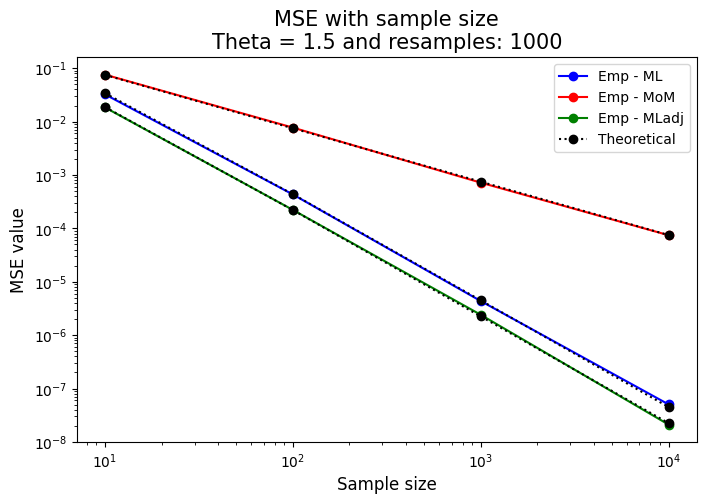

In [ ]:
plt.figure(figsize = (8, 5))

# Empirical results
plt.plot(n_list, mse_list_emp[0, :], '-o', color="blue", label = "Emp - ML")
plt.plot(n_list, mse_list_emp[1, :], '-o', color="red", label = "Emp - MoM")
plt.plot(n_list, mse_list_emp[2, :], '-o', color="green", label = "Emp - MLadj")

# Theoretical results
plt.plot(n_list, mse_list_theo[0, :], '-o', color="black", label = "Theoretical",
         linestyle = ":")
plt.plot(n_list, mse_list_theo[1, :], '-o', color="black", linestyle = ":")
plt.plot(n_list, mse_list_theo[2, :], '-o', color="black", linestyle = ":")

plt.title(f"MSE with sample size\nTheta = {theta} and resamples: {N_data}",
          fontsize = 15)
plt.xlabel("Sample size", fontsize = 12)
plt.ylabel("MSE value", fontsize = 12)

plt.xscale('log')
plt.yscale('log')

plt.legend()
plt.show()